# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

## Business Understanding

**Business objective**
The dealership wants to know which characteristics (such as age, mileage, brand, condition, and fuel type) raise or lower a used car's price, and by how much. This will help them decide which types of cars to stock in their inventory, which cars to avoid, and how to price them.

**Data problem definition**
I frame this as a supervised regression problem. The target variable is `price`, and the features are the remaining listing attributes: `year`, `odometer`, `manufacturer`, `condition`, `cylinders`, `fuel`, `title_status`, `transmission`, `drive`, `type`, `paint_color`, and `state`. I will train several regression models and use them in two ways:

1. to predict price reasonably well, and
2. to interpret which features push price up or down, and by how much.

Since the client cares about *why* prices differ, I will favor models whose coefficients I can explain, even if that costs a little accuracy.

**Success criteria**

The project succeeds if:
1. the model clearly beats a baseline that always predicts the average price,
2. its typical prediction error is small relative to the car's price (I found about 20% on held-out data), and
3. I can deliver a ranked, plain-language list of the features that drive price.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent, clean plot style for the whole notebook
sns.set_theme(style='whitegrid')

In [2]:
# Load the used car listings
cars = pd.read_csv('data/vehicles.csv')

print(f'Rows: {cars.shape[0]:,}  Columns: {cars.shape[1]}')
cars.head(20)

Rows: 426,880  Columns: 18


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
5,7222379453,hudson valley,1600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
6,7221952215,hudson valley,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
7,7220195662,hudson valley,15995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
8,7209064557,medford-ashland,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,or
9,7219485069,erie,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pa


In [3]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

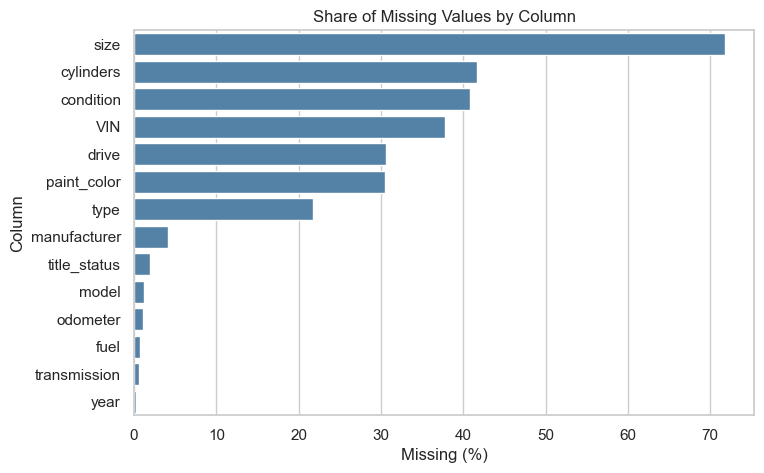

In [4]:
# Percent of missing values per column, only columns with at least one missing
missing_pct = (cars.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color='steelblue', ax=ax)
ax.set(title='Share of Missing Values by Column',
       xlabel='Missing (%)', ylabel='Column');


In [5]:
# Summary statistics for the target, including extreme percentiles
cars['price'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(0)


count    4.268800e+05
mean     7.519900e+04
std      1.218228e+07
min      0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648600e+04
95%      4.450000e+04
99%      6.699500e+04
max      3.736929e+09
Name: price, dtype: float64

In [6]:
# How many listings have a price of exactly $0?
zero_price_count = (cars['price'] == 0).sum()
print(f'Listings priced at $0: {zero_price_count:,} ({zero_price_count / len(cars):.1%})')

Listings priced at $0: 32,895 (7.7%)


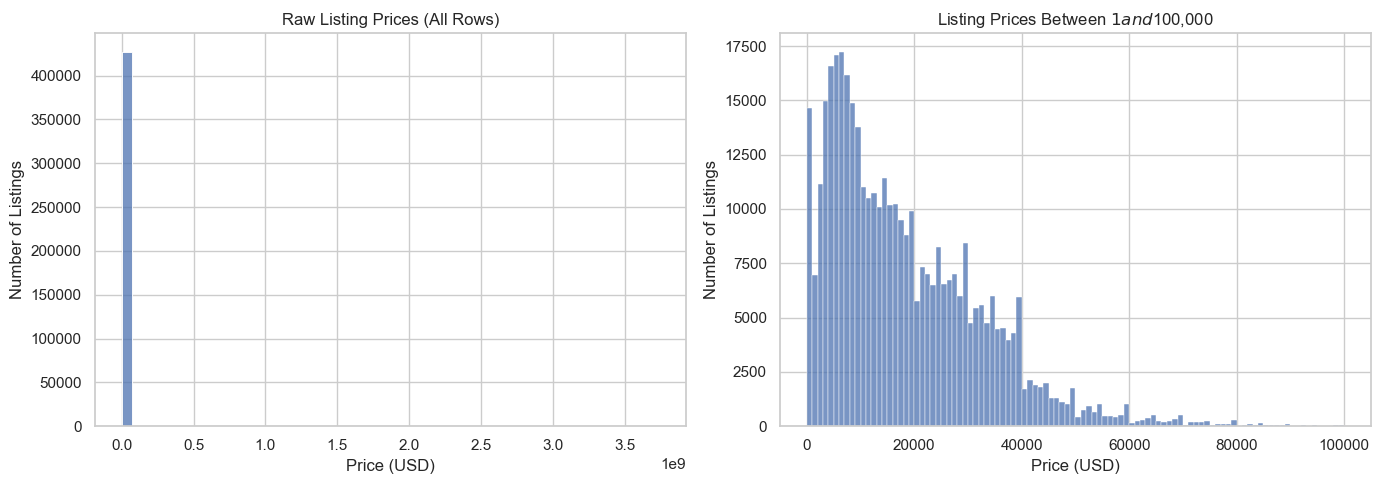

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw prices, including extreme values
sns.histplot(cars['price'], bins=50, ax=axes[0])
axes[0].set(title='Raw Listing Prices (All Rows)',
            xlabel='Price (USD)', ylabel='Number of Listings')

# Right: a realistiv range, for display only (no rows removed yet)
price_window = cars.loc[cars['price'].between(1, 100_000), 'price']
sns.histplot(price_window, bins=100, ax=axes[1])
axes[1].set(title='Listing Prices Between $1 and $100,000',
            xlabel='Price (USD)', ylabel='Number of Listings')

plt.tight_layout();
plt.savefig('images/listing_prices_rawVSrealistic.png', dpi=150, bbox_inches='tight');

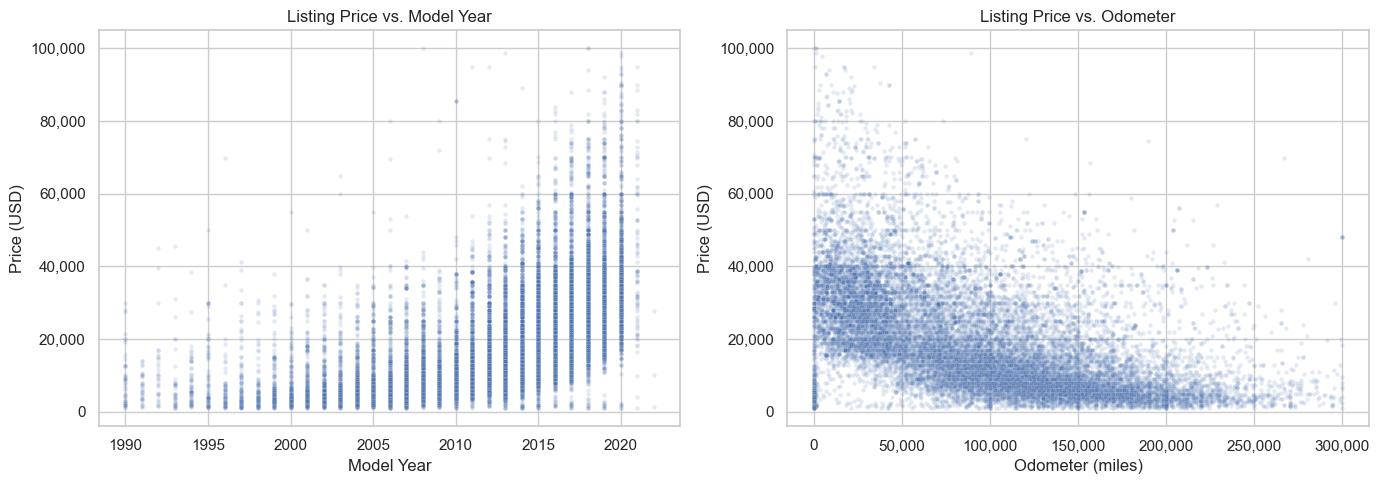

In [8]:
# Year and odometer vs. price
# Plotting subset: realistic prices, mileage, and years, then a random sample
# (426k points would render as a solid blob and plot slowly)
plot_sample = (
    cars.query('price.between(1000, 100000) and odometer <= 300000 and year >= 1990')
        .sample(20_000, random_state=42)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=plot_sample, x='year', y='price', alpha=0.15, s=10, ax=axes[0])
axes[0].set(title='Listing Price vs. Model Year',
            xlabel='Model Year', ylabel='Price (USD)')

sns.scatterplot(data=plot_sample, x='odometer', y='price', alpha=0.15, s=10, ax=axes[1])
axes[1].set(title='Listing Price vs. Odometer',
            xlabel='Odometer (miles)', ylabel='Price (USD)')

# Comma formatting on both price axes and the odometer axis
comma_fmt = plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
for ax in axes:
    ax.yaxis.set_major_formatter(comma_fmt)
axes[1].xaxis.set_major_formatter(comma_fmt)

plt.tight_layout();
plt.savefig('images/listing_pricesVSyear_miles.png', dpi=150, bbox_inches='tight');

In [9]:
# Linear correlation between the numeric features and price (on the plotting sample)
plot_sample[['year', 'odometer', 'price']].corr().round(2)

,year,odometer,price
year,1.00,-0.64,0.59
odometer,-0.64,1.00,-0.55
price,0.59,-0.55,1.00


In [10]:
# Summary statistics for the target, including extreme percentiles
cars['year'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(0)


count    425675.0
mean       2011.0
std           9.0
min        1900.0
1%         1967.0
5%         1998.0
25%        2008.0
50%        2013.0
75%        2017.0
95%        2020.0
99%        2020.0
max        2022.0
Name: year, dtype: float64

In [11]:
# Summary statistics for the target, including extreme percentiles
cars['odometer'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(0)
(cars['odometer'] == 0).sum()

np.int64(1965)

In [12]:
# Realistic price window for plotting only; real cleaning happens in Data Preparation
price_display = cars.query('price.between(1000, 100000)')

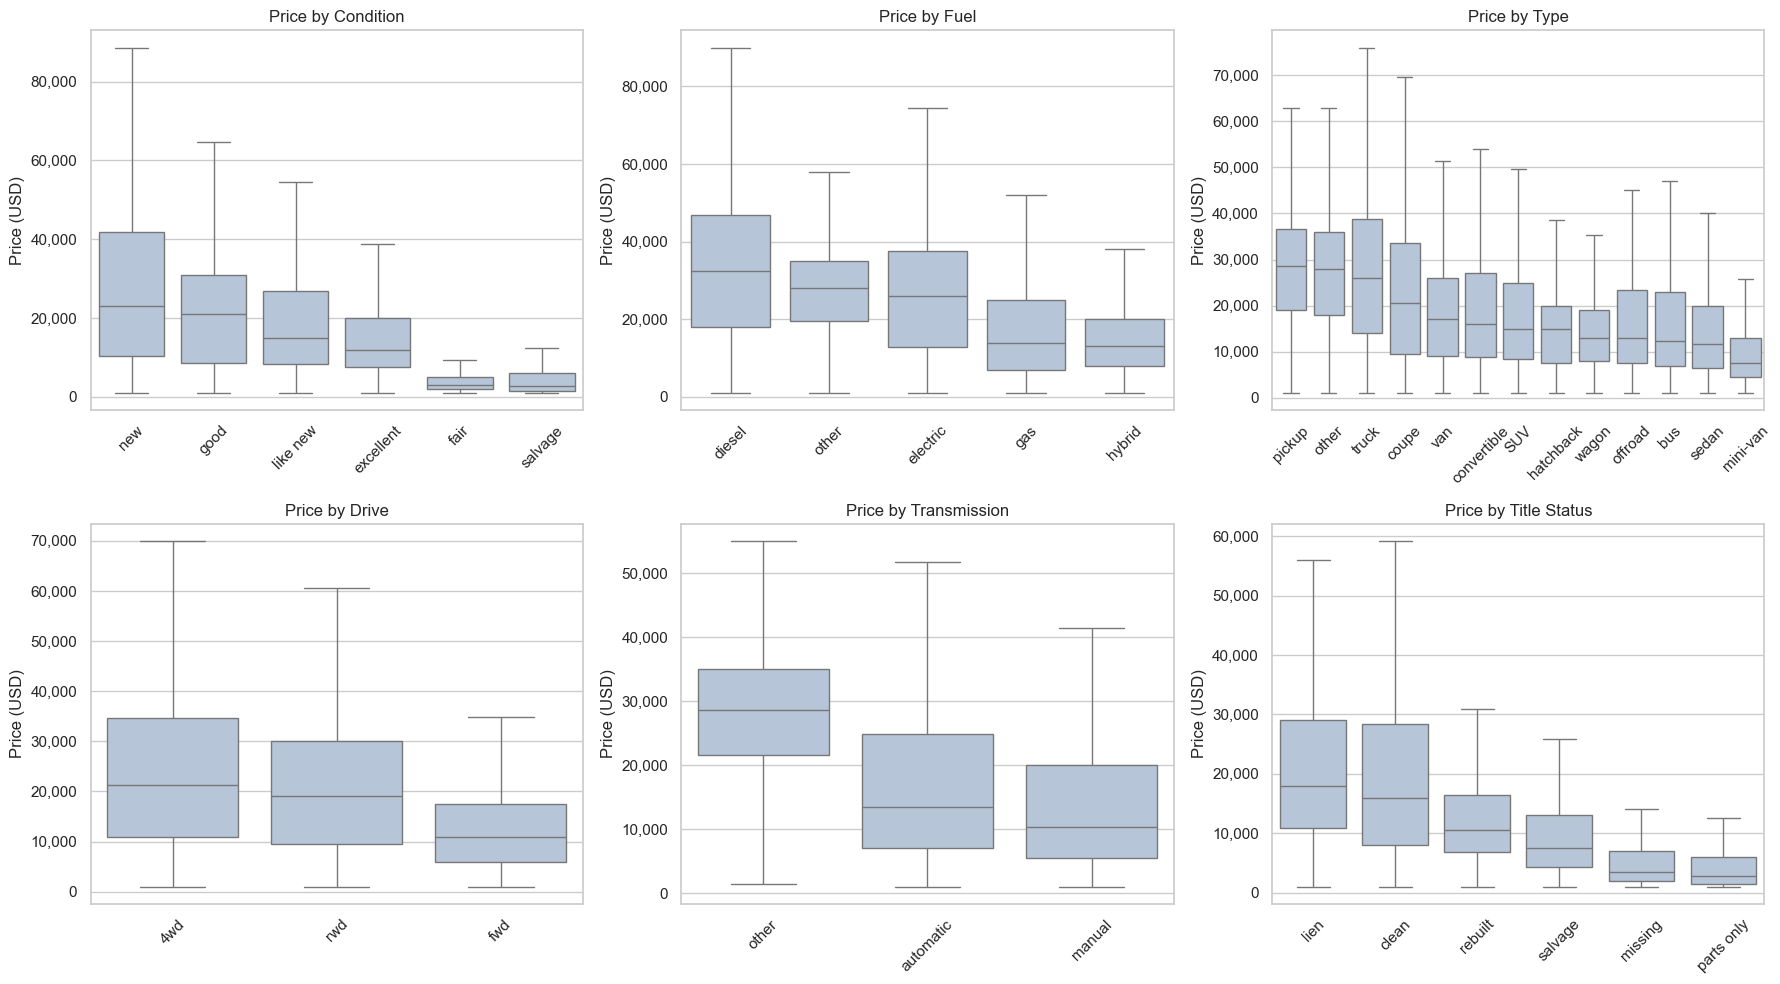

In [13]:
cat_cols = ['condition', 'fuel', 'type', 'drive', 'transmission', 'title_status']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flat, cat_cols):
    # Order boxes from highest to lowest median price so the ranking is easy to read
    order = (price_display.groupby(col)['price']
                          .median()
                          .sort_values(ascending=False)
                          .index)
    sns.boxplot(data=price_display, x=col, y='price', order=order,
                showfliers=False, color='lightsteelblue', ax=ax)
    ax.set(title=f'Price by {col.replace("_", " ").title()}',
           xlabel='', ylabel='Price (USD)')
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout();
plt.savefig('images/listing_pricesVScategory_cols.png', dpi=150, bbox_inches='tight');

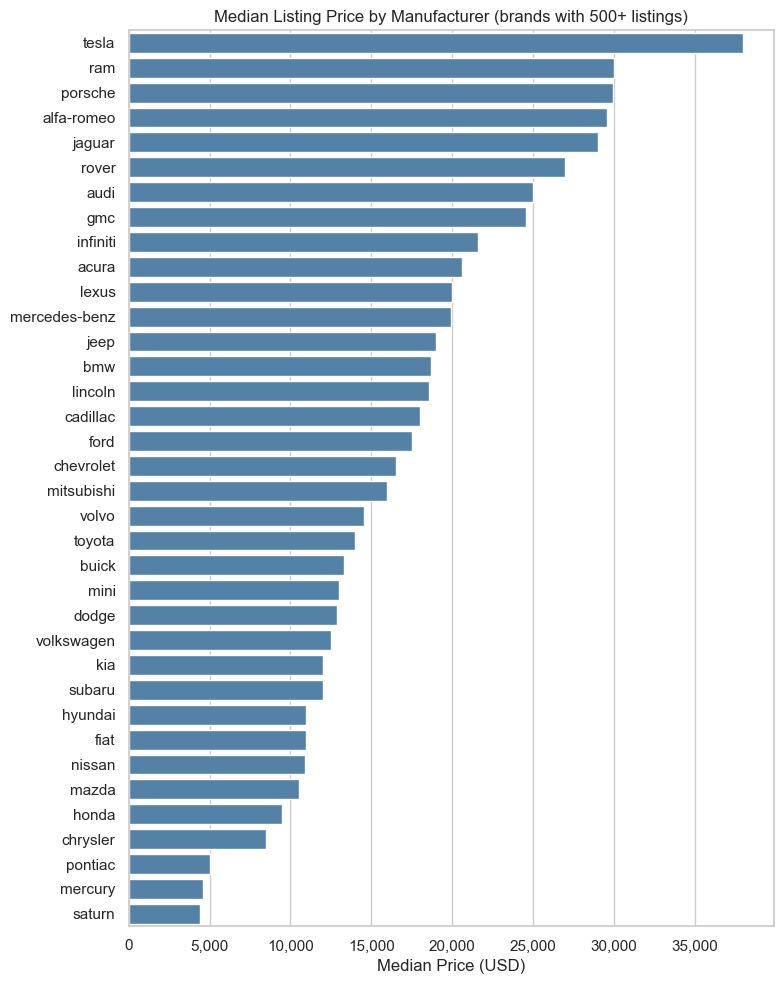

In [14]:
# Median price and listing count per manufacturer; keep brands with enough data to trust
maker_stats = (price_display.groupby('manufacturer')['price']
                            .agg(median_price='median', listings='count')
                            .query('listings >= 500')
                            .sort_values('median_price', ascending=False))

fig, ax = plt.subplots(figsize=(8, 10))
sns.barplot(data=maker_stats.reset_index(), x='median_price', y='manufacturer',
            color='steelblue', ax=ax)
ax.set(title='Median Listing Price by Manufacturer (brands with 500+ listings)',
       xlabel='Median Price (USD)', ylabel='')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout();
plt.savefig('images/median_listing_prices_by_make.png', dpi=150, bbox_inches='tight');

In [15]:
# Is condition confounded with age and mileage? Compare typical year and odometer per label
price_display.groupby('condition')[['year', 'odometer']].median().round(0)

,year,odometer
condition,,
excellent,2012.0,104619.0
fair,2002.0,165000.0
good,2015.0,51912.0
like new,2014.0,75369.0
new,2018.0,15000.0
salvage,2006.0,130000.0


In [16]:
# Are the cheapest brands simply older cars?
price_display.groupby('manufacturer')['year'].median().loc[['pontiac', 'mercury', 'saturn', 'tesla', 'ram']]

manufacturer
pontiac    2006.0
mercury    2004.0
saturn     2007.0
tesla      2018.0
ram        2015.0
Name: year, dtype: float64

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [17]:
# Remove columns that are not useful:
#   id, VIN  -> unique identifiers, no predictive meaning
#   region   -> 404 Craigslist areas; 'state' captures location more simply
#   model    -> ~30k free-text values, too complex to generalize
#   size     -> 72% missing
cars_clean = cars.drop(columns=['id', 'VIN', 'region', 'model', 'size'])

In [18]:
# Track how many rows each cleaning step removes
cleaning_log = [('Raw data', len(cars))]

def log_step(df, label):
    """Record the row count after a cleaning step and return the DataFrame unchanged."""
    cleaning_log.append((label, len(df)))
    return df

cars_clean = log_step(cars_clean.drop_duplicates(),
                      'Remove duplicate listings')
cars_clean = log_step(cars_clean.query('1000 <= price <= 100000'),
                      'Price between 1,000 and 100,000 USD')
cars_clean = log_step(cars_clean.query('1990 <= year <= 2021'),
                      'Model year 1990 to 2021')
cars_clean = log_step(cars_clean.query('0 < odometer <= 200000'),
                      'Odometer between 1 and 200,000 miles')

In [19]:
log_table = pd.DataFrame(cleaning_log, columns=['step', 'rows_remaining'])
log_table['rows_removed'] = (-log_table['rows_remaining'].diff()).fillna(0).astype(int)
log_table

,step,rows_remaining,rows_removed
0,Raw data,426880,0
1,Remove duplicate listings,296456,130424
2,"Price between 1,000 and 100,000 USD",268026,28430
3,Model year 1990 to 2021,256283,11743
4,"Odometer between 1 and 200,000 miles",237670,18613


In [20]:
# Age is easier to explain to a dealer than model year (listings collected around 2021)
cars_clean['age'] = 2021 - cars_clean['year']

# Log of price: reduces right skew and turns coefficients into approximate % effects
cars_clean['log_price'] = np.log(cars_clean['price'])

# Categorical columns: treat 'not reported' as its own category instead of dropping rows
cat_cols = ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status',
            'transmission', 'drive', 'type', 'paint_color', 'state']
cars_clean[cat_cols] = cars_clean[cat_cols].fillna('unknown')

# Confirm nothing is missing anymore
cars_clean.isna().sum().sum()

np.int64(0)

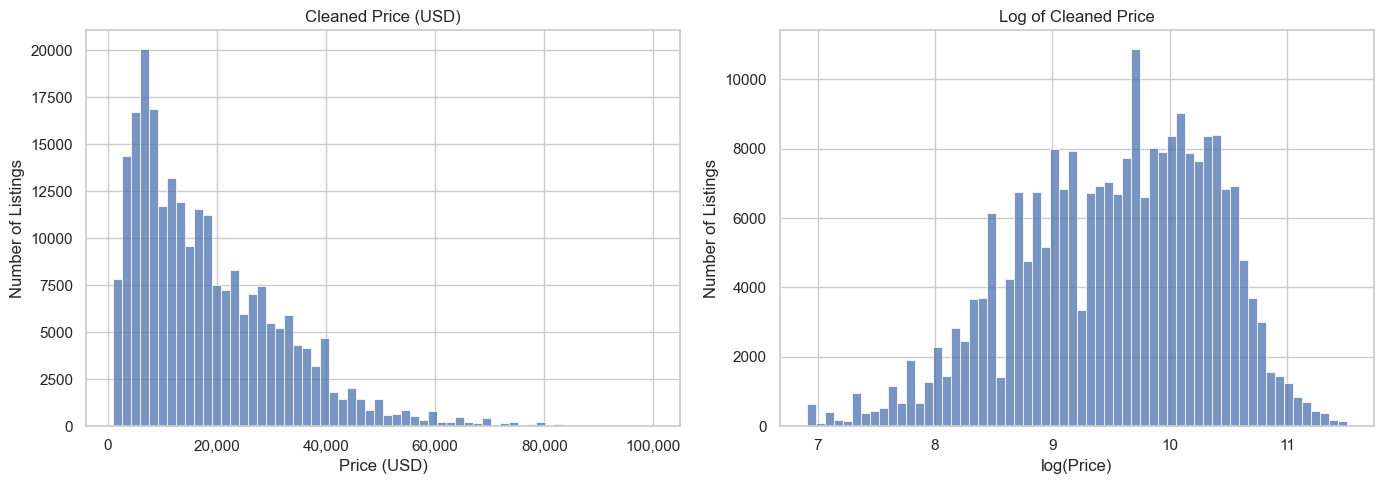

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(cars_clean['price'], bins=60, ax=axes[0])
axes[0].set(title='Cleaned Price (USD)', xlabel='Price (USD)', ylabel='Number of Listings')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.histplot(cars_clean['log_price'], bins=60, ax=axes[1])
axes[1].set(title='Log of Cleaned Price', xlabel='log(Price)', ylabel='Number of Listings')

plt.tight_layout();
plt.savefig('images/cleaned_prices.png', dpi=150, bbox_inches='tight');

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [22]:
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error

In [23]:
# Features, target, and train/test split
num_features = ['age', 'odometer']
cat_features = ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status',
                'transmission', 'drive', 'type', 'paint_color', 'state']

X = cars_clean[num_features + cat_features]
y = cars_clean['log_price']

# Hold out 20% of cars as a final test set; it is not touched until the very end
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training rows: {len(X_train):,}  Test rows: {len(X_test):,}')

Training rows: 190,136  Test rows: 47,534


In [24]:
# Scale numeric columns; one-hot encode categorical columns
# min_frequency=500 groups rare categories (e.g., small brands) into one 'infrequent' column
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist',
                          min_frequency=500, sparse_output=False), cat_features),
])

In [25]:
# Cross validation setup

# 5-fold CV, shuffled, reproducible
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse(model, label):
    """Cross-validate a model inside the preprocessing pipeline; return mean train/validation RMSE."""
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=kfold,
                            scoring='neg_root_mean_squared_error',
                            return_train_score=True)
    return {'model': label,
            'train_rmse': -scores['train_score'].mean(),
            'val_rmse': -scores['test_score'].mean()}

In [26]:
# Baseline: always predict the average log price. Every real model must beat this.
results = [
    cv_rmse(DummyRegressor(strategy='mean'), 'Baseline (mean)'),
    cv_rmse(LinearRegression(), 'Linear Regression'),
]

results_table = pd.DataFrame(results).round(3)
results_table

,model,train_rmse,val_rmse
0,Baseline (mean),0.833,0.833
1,Linear Regression,0.424,0.424


In [27]:
# Helper to record grid search results
def grid_summary(grid, label):
    """Pull the best model's mean train/validation RMSE from a fitted GridSearchCV."""
    best = grid.best_index_
    return {'model': label,
            'train_rmse': -grid.cv_results_['mean_train_score'][best],
            'val_rmse': -grid.best_score_}

In [29]:
# Lasso with a grid search over alpha
lasso_pipe = Pipeline([('prep', preprocessor), ('model', Lasso(max_iter=5000))])

lasso_grid = GridSearchCV(lasso_pipe,
                          param_grid={'model__alpha': [0.0001, 0.001, 0.01, 0.1]},
                          cv=kfold, scoring='neg_root_mean_squared_error',
                          return_train_score=True, n_jobs=-1)
lasso_grid.fit(X_train, y_train)

print('Best Lasso alpha:', lasso_grid.best_params_['model__alpha'])

Best Lasso alpha: 0.0001


In [30]:
# Polynomial features on age and odometer, plus Ridge

# Polynomial terms (age^2, odometer^2, age*odometer, ...) for the numeric columns only
poly_numeric = Pipeline([('poly', PolynomialFeatures(include_bias=False)),
                         ('scale', StandardScaler())])

poly_preprocessor = ColumnTransformer([
    ('num', poly_numeric, num_features),
    ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist',
                          min_frequency=500, sparse_output=False), cat_features),
])

poly_pipe = Pipeline([('prep', poly_preprocessor), ('model', Ridge())])

poly_grid = GridSearchCV(poly_pipe,
                         param_grid={'prep__num__poly__degree': [1, 2, 3],
                                     'model__alpha': [1, 10, 100]},
                         cv=kfold, scoring='neg_root_mean_squared_error',
                         return_train_score=True, n_jobs=-1)
poly_grid.fit(X_train, y_train)

print('Best polynomial settings:', poly_grid.best_params_)

Best polynomial settings: {'model__alpha': 1, 'prep__num__poly__degree': 3}


In [31]:
# Ridge with a grid search over alpha
ridge_pipe = Pipeline([('prep', preprocessor), ('model', Ridge())])

ridge_grid = GridSearchCV(ridge_pipe,
                          param_grid={'model__alpha': [0.1, 1, 10, 100, 1000]},
                          cv=kfold, scoring='neg_root_mean_squared_error',
                          return_train_score=True, n_jobs=-1)
ridge_grid.fit(X_train, y_train)

print('Ridge alpha:', ridge_grid.best_params_)
print('Lasso alpha:', lasso_grid.best_params_)
print('Polynomial + Ridge:', poly_grid.best_params_)
print('Best Ridge alpha:', ridge_grid.best_params_['model__alpha'])

Ridge alpha: {'model__alpha': 10}
Lasso alpha: {'model__alpha': 0.0001}
Polynomial + Ridge: {'model__alpha': 1, 'prep__num__poly__degree': 3}
Best Ridge alpha: 10


In [32]:
# Full comparison table

results += [grid_summary(ridge_grid, 'Ridge'),
            grid_summary(lasso_grid, 'Lasso'),
            grid_summary(poly_grid, 'Polynomial + Ridge')]

results_table = pd.DataFrame(results).round(3)
results_table

,model,train_rmse,val_rmse
0,Baseline (mean),0.833,0.833
1,Linear Regression,0.424,0.424
2,Ridge,0.424,0.424
3,Lasso,0.424,0.424
4,Polynomial + Ridge,0.410,0.410


In [33]:
print('Ridge alpha:', ridge_grid.best_params_)
print('Lasso alpha:', lasso_grid.best_params_)
print('Polynomial + Ridge:', poly_grid.best_params_)

Ridge alpha: {'model__alpha': 10}
Lasso alpha: {'model__alpha': 0.0001}
Polynomial + Ridge: {'model__alpha': 1, 'prep__num__poly__degree': 3}


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [34]:
# Final test sets 
# Final models to compare on the untouched test set
final_models = {
    'Baseline (mean)':    None,
    'Ridge (linear)':     ridge_grid.best_estimator_,
    'Polynomial + Ridge': poly_grid.best_estimator_,
}

actual_price = np.exp(y_test)   # back to dollars
test_rows = []

for label, model in final_models.items():
    if model is None:
        # Baseline: predict the average training log price for every car
        pred_price = np.full(len(y_test), np.exp(y_train.mean()))
    else:
        pred_price = np.exp(model.predict(X_test))

    pct_error = np.abs(pred_price - actual_price) / actual_price
    test_rows.append({'model': label,
                      'MAE ($)': mean_absolute_error(actual_price, pred_price),
                      'median % error': np.median(pct_error) * 100})

test_table = pd.DataFrame(test_rows).round(1)
test_table

,model,MAE ($),median % error
0,Baseline (mean),10696.7,54.0
1,Ridge (linear),4680.3,20.4
2,Polynomial + Ridge,4586.7,19.8


## For a typical car, my model's price estimate is within about 20% of the listing price, and on average it's off by about $4,600.

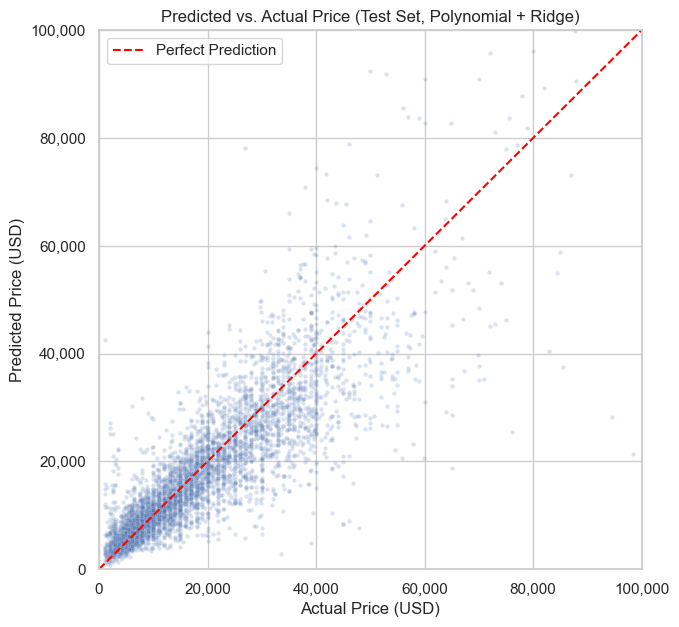

In [35]:
# Predicted vs. actual plot
best_model = poly_grid.best_estimator_
plot_df = pd.DataFrame({'actual': actual_price,
                        'predicted': np.exp(best_model.predict(X_test))}).sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(7, 7))
sns.scatterplot(data=plot_df, x='actual', y='predicted', alpha=0.2, s=10, ax=ax)
ax.plot([0, 100_000], [0, 100_000], color='red', linestyle='--', label='Perfect Prediction')
ax.set(title='Predicted vs. Actual Price (Test Set, Polynomial + Ridge)',
       xlabel='Actual Price (USD)', ylabel='Predicted Price (USD)',
       xlim=(0, 100_000), ylim=(0, 100_000))
comma_fmt = plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
ax.xaxis.set_major_formatter(comma_fmt)
ax.yaxis.set_major_formatter(comma_fmt)
ax.legend();
plt.savefig('images/predicte_VS_actual.png', dpi=150, bbox_inches='tight');

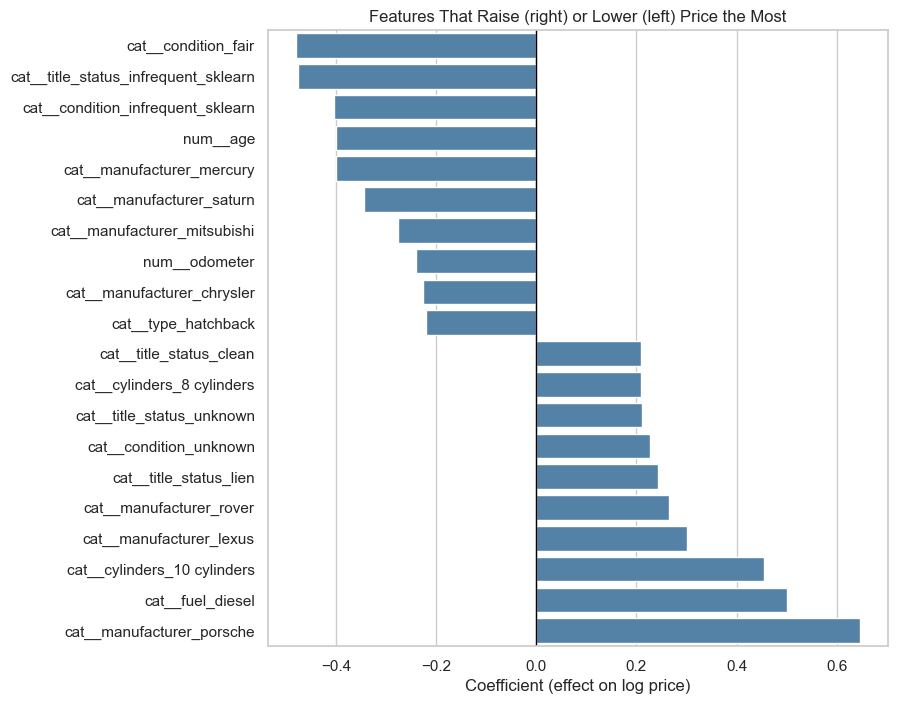

In [36]:
# Biggest positive and negative coefficients

# Coefficients from the Ridge model, matched to feature names
ridge_model = ridge_grid.best_estimator_
feature_names = ridge_model.named_steps['prep'].get_feature_names_out()
coefs = pd.Series(ridge_model.named_steps['model'].coef_, index=feature_names)

# 10 features that raise price the most and 10 that lower it the most
top_coefs = pd.concat([coefs.sort_values().head(10), coefs.sort_values().tail(10)])

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(x=top_coefs.values, y=top_coefs.index, color='steelblue', ax=ax)
ax.axvline(0, color='black', linewidth=1)
ax.set(title='Features That Raise (right) or Lower (left) Price the Most',
       xlabel='Coefficient (effect on log price)', ylabel='');
plt.savefig('images/models_coefficients.png', dpi=150, bbox_inches='tight');

## Holding age, mileage, and everything else the same, luxury brands (Porsche, Lexus), diesel engines, and big engines (10 cylinders) sell for noticeably more.

manufacturer: ['alfa-romeo', 'aston-martin', 'ferrari', 'fiat', 'harley-davidson', 'land rover', 'morgan', 'tesla']
condition: ['salvage']
cylinders: ['12 cylinders', '3 cylinders']
title_status: ['missing', 'parts only']
type: ['bus', 'offroad']
paint_color: ['purple']
state: ['nd', 'wy']


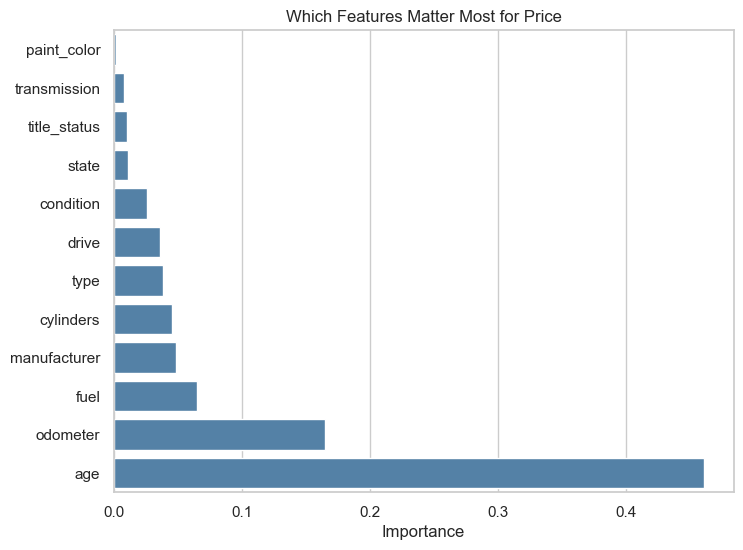

In [37]:
# Which features matter most overall

from sklearn.inspection import permutation_importance  

perm = permutation_importance(ridge_model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
# Which rare categories were grouped into 'infrequent_sklearn' for each feature
importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()
encoder = ridge_model.named_steps['prep'].named_transformers_['cat']
for feature, rare in zip(cat_features, encoder.infrequent_categories_):
    if rare is not None:
        print(f'{feature}: {list(rare)}')

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=importance.values, y=importance.index, color='steelblue', ax=ax)
ax.set(title='Which Features Matter Most for Price', xlabel='Importance', ylabel='');
plt.savefig('images/features_importance.png', dpi=150, bbox_inches='tight');

1. Age is by far the biggest driver, more than twice as important as anything else.
2. Odometer (mileage) is second.
3. Fuel is third, mostly because of the diesel premium.

Then brand, cylinders, type, and drive follow, and paint color barely matters at all.

In [38]:
# Convert age and mileage coefficients into % price change per real-world unit
scaler = ridge_model.named_steps['prep'].named_transformers_['num']
age_coef, odometer_coef = coefs[['num__age', 'num__odometer']].values / scaler.scale_

print(f'Each additional year of age:  {(np.exp(age_coef) - 1) * 100:.1f}% change in price')
print(f'Each additional 10,000 miles: {(np.exp(odometer_coef * 10_000) - 1) * 100:.1f}% change in price')

Each additional year of age:  -6.6% change in price
Each additional 10,000 miles: -4.3% change in price


In [39]:
# Which rare categories were grouped into 'infrequent_sklearn' for each feature
encoder = ridge_model.named_steps['prep'].named_transformers_['cat']
for feature, rare in zip(cat_features, encoder.infrequent_categories_):
    if rare is not None:
        print(f'{feature}: {list(rare)}')

manufacturer: ['alfa-romeo', 'aston-martin', 'ferrari', 'fiat', 'harley-davidson', 'land rover', 'morgan', 'tesla']
condition: ['salvage']
cylinders: ['12 cylinders', '3 cylinders']
title_status: ['missing', 'parts only']
type: ['bus', 'offroad']
paint_color: ['purple']
state: ['nd', 'wy']


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

## Findings and Recommendations

### What drives the price of a used car?

We analyzed about 238,000 used car listings to find which characteristics make a car worth more or less, comparing cars that are otherwise similar. Our key findings:

**1. Age and mileage matter most.**
These two factors drive price more than anything else. Holding everything else equal, a car loses about **6.6% of its value for each additional year of age** and about **4.3% for every additional 10,000 miles**. Price decrease is steepest early in a car's life and slows down as the car gets older.

**2. Trucks, diesel engines, and larger engines hold a premium.**
Pickups and trucks sell for noticeably more than comparable sedans. Diesel vehicles and cars with 8 or more cylinders also command higher prices, even after accounting for vehicle type. Four-wheel drive and rear-wheel drive cars sell for more than front-wheel drive cars.

**3. Brand matters, especially at the luxury end.**
Brands such as Porsche and Lexus sell for significantly more than comparable mainstream cars, while discontinued or budget brands (such as Mercury and Saturn) sell for less, even at the same age and mileage.

**4. Title problems and poor condition sharply reduce value.**
Cars with salvage, rebuilt, missing, or parts-only titles, and cars listed in fair or salvage condition, sell for far less than comparable cars with a clean title in good condition.

**5. Paint color barely matters.**
Of all the features we tested, color had almost no effect on price.

### Recommendations for your inventory

- **Prioritize newer, lower-mileage vehicles.** Since age and mileage drive most of a car's value, these are the most reliable inventory to buy and price.
- **Stock trucks, pickups, and 4WD vehicles.** They consistently hold their value better than sedans and hatchbacks.
- **Look for diesel and larger-engine vehicles,** which carry a clear price premium.
- **Be cautious with salvage, rebuilt, or missing-title vehicles.** They lose a large share of their value, so only buy them at a deep discount.
- **Don't pay extra for color.** Buyers don't value it much.
- **Use our price model as a starting point, not a final price.** For typical cars, it estimates the price within about 20%. It works best for cars in the 5,000 to 35,000 USD range, and it is less reliable for budget cars and premium vehicles.

### Limitations

- The data comes from online listings, so prices are **asking prices**, not final sale prices.
- Condition is **reported by the seller** and can be subjective.
- The data doesn't include important details such as **trim level, accident history, or options**, which explains why some predictions are off.
- Our findings apply to cars priced between 1,000 and 100,000 USD, model years 1990 to 2021, with up to 200,000 miles.

## Next Steps

- **Add richer data** such as trim level, accident history (for example, from VIN reports), and car options. This is the most likely way to improve accuracy.
- **Use actual sale prices** instead of asking prices if the dealership can provide its own sales records.
- **Update the analysis regularly,** since used car prices shift with the market.